In [1]:
%load_ext autoreload
%autoreload 2

# Portfolio contruction

The aim of this excersise is to group of stocks and cluster them into different groups based on specific financial metrics.

We will further perform correlation analysis with ESG scores and will select stocks to build risk-adjusted portfolio to minimize risk for a given level of return. 

The data is publicly available via Yahoo finance. Unfortunately, there is a limitation in data coverage as we don't have access to Factset or Bloomberg datasets.

Clustred portfolio will be 

There are a number clustering algorithms we can use, but for the perpose of this excersise - we will be looking into K-Means . **K-Means is an unsupervised machine learning algorithm which is used on unlabeled data (i.e., data without defined categories or groups). The goal of the K-Means algorithm is to divide `n` data points into `k` partitions, where the sum of the distances is minimized.**

***

**Broken into steps, the algorithm is executed in the following order:**

1. Randomly select K-Centers, to be the cluster centers.
2. Calculate the distance of each point to a cluster, and assign a cluster label where the Euclidean distance is smallest.
3. Recompute the centroids by taking the mean of all the data points assigned to that cluster.
4. Repeat these steps until one of the following two conditions are met:
    1. *The Sum of the Distances is minimized.*
    2. *The maximum number of iterations has been reached.*
    
    
***


In [2]:
import pandas as pd

## Load Data

In [3]:
# load the stock symbols into a data frame.
instruments_df = pd.read_csv("data/instruments.csv")
fundamentals_df = pd.read_csv("data/fundamentals_data.csv")

In [4]:
display(instruments_df.head())

,symbol,security_name,sector,sub_industry,date_added
0,MMM,3M,Industrials,Industrial Conglomerates,1957-03-04
1,AOS,A. O. Smith,Industrials,Building Products,2017-07-26
2,ABT,Abbott Laboratories,Health Care,Health Care Equipment,1957-03-04
3,ABBV,AbbVie,Health Care,Biotechnology,2012-12-31
4,ACN,Accenture,Information Technology,IT Consulting & Other Services,2011-07-06


In [5]:
display(fundamentals_df.head())

,symbol,current_price,return_on_equity,return_on_assets,debt_to_equity,current_ratio,quick_ratio,revenue,ebitda,free_cash_flow,...,rating_year,rating_month,adult,animal_testing,gambling,small_arm,furLeather,coal,controversial_weapons,tobacco
0,MMM,144.03,0.93824,0.05448,312.492,1.657,1.114,24512999424,5.328000e+09,3.745000e+08,...,2025.0,6.0,False,False,False,False,False,False,False,False
1,AOS,62.74,0.27970,0.13353,15.945,1.612,0.954,3803200000,7.689000e+08,3.449500e+08,...,2025.0,6.0,False,False,False,False,False,False,False,False
2,ABT,132.99,0.30649,0.06377,27.087,1.780,1.090,42344001536,1.102100e+10,6.032375e+09,...,2025.0,6.0,False,True,False,False,False,False,False,False
3,ABBV,185.30,0.88400,0.08339,4789.603,0.760,0.485,57366999040,2.736600e+10,1.694138e+10,...,2025.0,6.0,False,True,False,False,False,False,False,False
4,ACN,285.37,0.26928,0.11245,25.881,1.461,1.318,68482535424,1.176778e+10,9.149395e+09,...,2025.0,6.0,False,False,False,False,False,False,False,False


## Feature Selection
***
We are looking into

1. **Return on Assets:** Return on assets (ROA) is an indicator of how profitable a company is relative to its total assets.<br></br>
   

2. **Return on Equity:** Return on equity (ROE) is a measure of financial performance calculated by dividing net income by shareholders’ equity. ROE is considered a measure of how effectively management is using a company’s assets to create profits.
   


3. **EBITA:** Earnings Before Interest, Taxes, and Amortization (EBITA), is a financial metric used to assess a company's profitability and operating performance. It focuses on the core business operations by excluding the impact of interest, taxes, and amortization expenses. Provides insights into operational profitability.

K-Means cannot handle missing data so it must be either removed from the data set or impute. 

In [6]:
# define our indicators list
features_list = ['symbol','return_on_equity','return_on_assets','ebitda']

# select only those columns
indicators_df = fundamentals_df[features_list]


# clustering can't handle missing values, so we need to eliminate any row that has a missing value.
indicators_df = indicators_df[indicators_df[features_list] != 0]
indicators_df = indicators_df.dropna(how='any')

In [7]:
# set the index
indicators_df.set_index('symbol', inplace=True)

# do a data type conversion
indicators_df = indicators_df.astype('float')

# indicators_df.dtypes

## Removing Outliers
***

We need to remove these extreme values from our data set or else they will skew our results using NYU Stern providing an industry benchmark for a wide range of financial metrics. This will serve as our baseline for removing extreme values from the data sets.

If you're interested in seeing this benchmarks, please go to the following link:
>*http://pages.stern.nyu.edu/~adamodar/New_Home_Page/datafile/pbvdata.html*
>*http://pages.stern.nyu.edu/~adamodar/New_Home_Page/datafile/pedata.html*


In [8]:
# define the filters
roe_filter = indicators_df.iloc[:,0] < 40
roa_filter = indicators_df.iloc[:,1] < 30

# get the counts for each column
roe_count = pd.Series(roe_filter).value_counts()
roa_count = pd.Series(roa_filter).value_counts()

# display the results
display(roe_count)
display(roa_count)

return_on_equity
True    447
Name: count, dtype: int64

return_on_assets
True    447
Name: count, dtype: int64

In [9]:
# filter the entire data frame
indicators_df = indicators_df[roe_filter & roa_filter]

Statistical summary

In [10]:
# create a statistical summary
desc_df = indicators_df.describe()

# add the standard deviation metric
desc_df.loc['+3_std'] = desc_df.loc['mean'] + (desc_df.loc['std'] * 3)
desc_df.loc['-3_std'] = desc_df.loc['mean'] - (desc_df.loc['std'] * 3)

# display it
desc_df

,return_on_equity,return_on_assets,ebitda
count,447.000000,447.000000,4.470000e+02
mean,0.321683,0.066284,7.462782e+09
std,1.022778,0.051951,1.739839e+10
min,-1.632120,-0.158370,-3.537000e+09
25%,0.089350,0.033455,1.652400e+09
50%,0.160520,0.055710,2.962993e+09
75%,0.302540,0.084590,6.267407e+09
max,16.057690,0.532450,1.491730e+11
+3_std,3.390018,0.222136,5.965794e+10
-3_std,-2.746652,-0.089568,-4.473238e+10


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D

## Visualization & Scale the Data
***
For the most part, the data is in a good range, there are a few values that are outside three standard deviations, but it's expected given the variety of stocks we have. Also, we will take steps later to mitigate this. Now that we've done a statistical summary, we can move on to plotting. In this example, let's use a 3D scatter plot to see all the data points. I will be using `matplotlib` to create our chart.

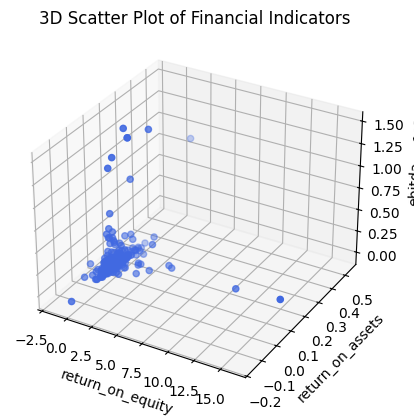

In [12]:
# create a 3D scatter plot
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

x = list(indicators_df.iloc[:,0])
y = list(indicators_df.iloc[:,1])
z = list(indicators_df.iloc[:,2])

ax.scatter(x, y, z, c='royalBlue', marker='o')

# define the axis labels
column_names = indicators_df.columns
ax.set_xlabel(column_names[0])
ax.set_ylabel(column_names[1])
ax.set_zlabel(column_names[2])


plt.title('3D Scatter Plot of Financial Indicators')
plt.show()


We need to normalize our data, to help handle outliers. Normalized data performs better and the following methods are widely used to achieve that:

1. **Standard Scaler:** Here we subtract the mean from each data point and divide it by the standard deviation. This method is sensitive to outliers; however, like computing, the mean means taking the average of ALL data points, including the outliers.

2. **Min Max Scaler:** Here we scale the data so that it fits in a range between 0 and 1. Mathematically we take each data point, subtract the minimum from it, and then divide it by the difference of the maximum value and the minimum value. Again, this is sensitive to outliers as the maximum amount would be the outlier.

3. **Robust Scaler:** This method is a better choice if your data has outliers. With this method, we use the interquartile range instead of the minimum and maximum, which helps control for outliers.

In our example, because there might be a possibility for outliers - we use the Robust Scaling method.

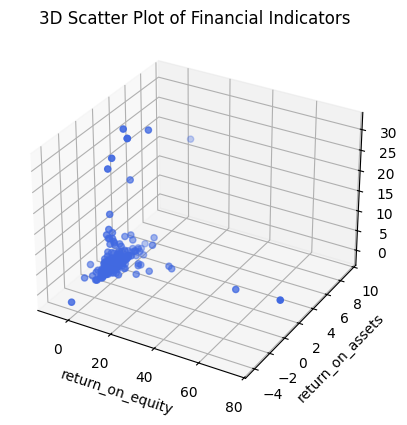

In [13]:
import numpy as np
from sklearn.preprocessing import Normalizer
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler

# for demonstration purposes, I will be creating all three instances of the scalers.
min_max_scaler = MinMaxScaler()
std_scaler = StandardScaler()
robust_scaler = RobustScaler()

# scale the data
X_train_minmax = min_max_scaler.fit_transform(indicators_df)
X_train_standard = std_scaler.fit_transform(indicators_df)
X_train_robust = robust_scaler.fit_transform(indicators_df)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

x = X_train_robust[:,0]
y = X_train_robust[:,1]
z = X_train_robust[:,2]

ax.scatter(x, y, z, c='royalBlue', marker='o')

# define the axis labels
column_names = indicators_df.columns
ax.set_xlabel(column_names[0])
ax.set_ylabel(column_names[1])
ax.set_zlabel(column_names[2])


plt.title('3D Scatter Plot of Financial Indicators')
plt.show()

## Principal Component Analysis
***
By scaling the data, we are allowing our algorithm to perform better with the data. Another topic we will discuss is the idea of Principal Component Analysis, which, with large data sets with multiple attributes, will allow our model to run faster and have less redundant data.

We need to understand a number of attributes which contribute the most and the number of these components.


Visually this can be done by passing through our scaled data set into our PCA class object, and plotting the `explained_variance_ratio` which will tell us how much of the variance is explained at any given number of components.

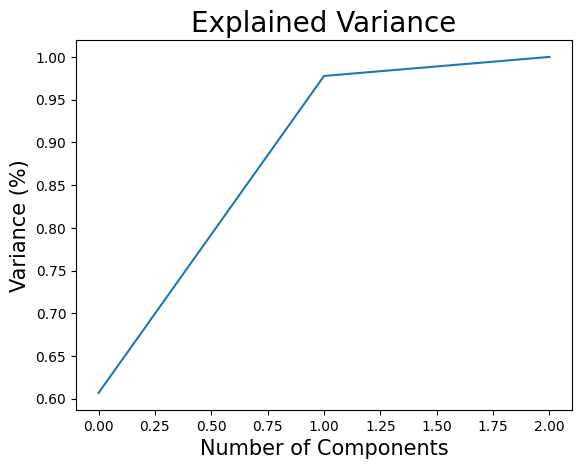

In [14]:
from sklearn.decomposition import PCA

# pass through the scaled data set into our PCA class object
pca = PCA().fit(X_train_robust)

# plot the Cumulative Summation of the Explained Variance
plt.figure()
plt.plot(np.cumsum(pca.explained_variance_ratio_))

# define the labels & title
plt.xlabel('Number of Components', fontsize = 15)
plt.ylabel('Variance (%)', fontsize = 15) 
plt.title('Explained Variance', fontsize = 20)

# show the plot
plt.show()

From the chart above, we can see that we have 100% of variance explained with only two components. This means that if we were to implement a PCA, we would select our number of components to be 2. In most examples, we won't get 100% explained the variance, but the general rule is to choose the minimum number of components that demonstrates the highest amount of variance.

**PCA for demonstration purposes, in a case with such few attributes as our example PCA is not justified.**

In [15]:
# create a PCA modified dataset
pca_dataset = PCA(n_components=2).fit(X_train_robust).transform(X_train_robust)

# store it in a new data frame
pca_dataset= pd.DataFrame(data = pca_dataset, columns = ['principal component 1', 'principal component 2'])

By running PCA, we have reduced the number of dimensions in our data set from 3 to 2; this means if we graph our new data frame, we will only have two dimensions. Let's see how the new data set would look graphically.

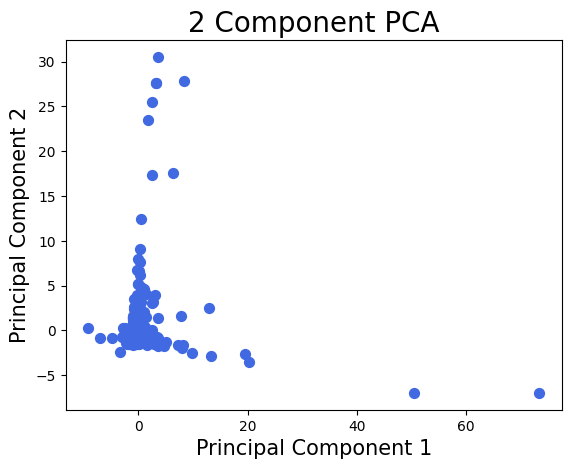

In [16]:
# define a figure
plt.figure()

# define the label and title
plt.xlabel('Principal Component 1', fontsize = 15)
plt.ylabel('Principal Component 2', fontsize = 15)
plt.title('2 Component PCA', fontsize = 20)

# plot the figure
plt.scatter(pca_dataset['principal component 1'], pca_dataset['principal component 2'], c='royalBlue', s = 50)

## Build & Run the Model
***

To determine the optimum number of clusters, we can utialize silhouette analysis.

Silhouette analysis can be used to study the separation distance between the resulting clusters. The silhouette plot displays a measure of how close each point in one cluster is to points in the neighboring clusters and thus provides a way to assess parameters like the number of clusters visually. This measure has a range of (-1, 1).

Silhouette coefficients (as these values are referred to as) near +1 indicate that the sample is far away from the neighboring clusters. A value of 0 indicates that the sample is on or very close to the decision boundary between two neighboring clusters and negative values indicate that those samples might have been assigned to the wrong cluster.

<br>*https://scikit-learn.org/stable/auto_examples/cluster/plot_kmeans_silhouette_analysis.html*</br>

We will create an instance of our KMeans model, and explore how the silhouette score changes within a limited range of clusters. From here, we will take the maximum score to determine our cluster.

In [17]:
from sklearn.cluster import KMeans
from sklearn import metrics

# define a dictionary that contains all of our relevant info.
results_dict = {}

# define how many clusters we want to test up to.
num_of_clusters = 10

# run through each instance of K
for k in range(2, num_of_clusters):
    
    print("-"*100)
    
    # define the next dictionary to hold all the results of this run.
    results_dict[k] = {}

    # create an instance of the model, and fit the training data to it.
    kmeans = KMeans(n_clusters=k, random_state=0).fit(X_train_robust)
    
    # define the silhouette score
    sil_score = metrics.silhouette_score(X_train_robust, kmeans.labels_, metric='euclidean')
    
    # store the different metrics
    results_dict[k]['silhouette_score'] = sil_score
    results_dict[k]['inertia'] = kmeans.inertia_
    results_dict[k]['score'] = kmeans.score
    results_dict[k]['model'] = kmeans
    
    # print the results    
    print("Number of Clusters: {}".format(k))
    print('Silhouette Score:', sil_score)

----------------------------------------------------------------------------------------------------
Number of Clusters: 2
Silhouette Score: 0.9411320689227233
----------------------------------------------------------------------------------------------------
Number of Clusters: 3
Silhouette Score: 0.8809172452271292
----------------------------------------------------------------------------------------------------
Number of Clusters: 4
Silhouette Score: 0.8071945436754268
----------------------------------------------------------------------------------------------------
Number of Clusters: 5
Silhouette Score: 0.6686623616688435
----------------------------------------------------------------------------------------------------
Number of Clusters: 6
Silhouette Score: 0.4952282108505214
----------------------------------------------------------------------------------------------------
Number of Clusters: 7
Silhouette Score: 0.493783330036746
-----------------------------------------

The first thing we should look at is the overall silhouette score, **ideally the larger the number, the better the results. However, this score is just part of the story, and we will have to examine the results to give ourselves a sanity check visually, but at this point, we can use the silhouette score as a gage of which ones we should target first.**

Looking at the results above, 2 or 3 should be our target.

Let's also run the results on our PCA data set to see what the output would look like. In this case, we get a higher silhouette score, which is a good sign, and it points to the same outcome, explore a cluster of 2 or 3.

In [18]:
# define a dictionary that contains all of our relevant info.
results_dict_pca = {}

# define how many clusters we want to test up to.
num_of_clusters = 10

# run through each instance of K
for k in range(2, num_of_clusters):
    
    print("-"*100)
    
    # define the next dictionary to hold all the results of this run.
    results_dict_pca[k] = {}

    # create an instance of the model, and fit the training data to it.
    kmeans = KMeans(n_clusters=k, random_state=0).fit(pca_dataset)
    
    # define the silhouette score
    sil_score = metrics.silhouette_score(pca_dataset, kmeans.labels_, metric='euclidean')
    
    # store the different metrics
    results_dict_pca[k]['silhouette_score'] = sil_score
    results_dict_pca[k]['inertia'] = kmeans.inertia_
    results_dict_pca[k]['score'] = kmeans.score
    results_dict_pca[k]['model'] = kmeans
    
    # print the results    
    print("Number of Clusters: {}".format(k))
    print('Silhouette Score:', sil_score)

----------------------------------------------------------------------------------------------------
Number of Clusters: 2
Silhouette Score: 0.9460138544836982
----------------------------------------------------------------------------------------------------
Number of Clusters: 3
Silhouette Score: 0.8932107468416611
----------------------------------------------------------------------------------------------------
Number of Clusters: 4
Silhouette Score: 0.831408976391129
----------------------------------------------------------------------------------------------------
Number of Clusters: 5
Silhouette Score: 0.716776988604334
----------------------------------------------------------------------------------------------------
Number of Clusters: 6
Silhouette Score: 0.4802029916897116
----------------------------------------------------------------------------------------------------
Number of Clusters: 7
Silhouette Score: 0.48083871459375044
-----------------------------------------

## Model Evaluation
With the help of a graphical aid, we can also analyze the results of our clusters. We can visualize the silhouette score for each point in that particular cluster. What we are looking for is that each cluster exceeds the red line or the average silhouette score and that the clusters are as evenly distributed as possible.


The high positive values are data points that would almost be in the center of the cluster and very easy to classify. I've provided a visual aid to help drive home the concept.

----------------------------------------------------------------------------------------------------


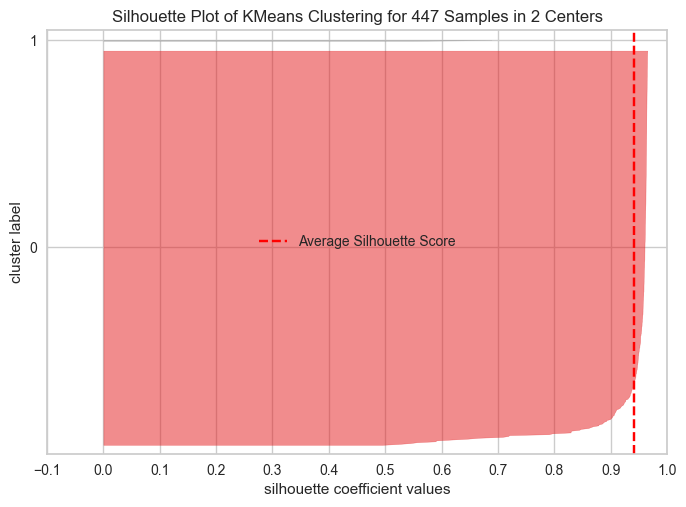

----------------------------------------------------------------------------------------------------


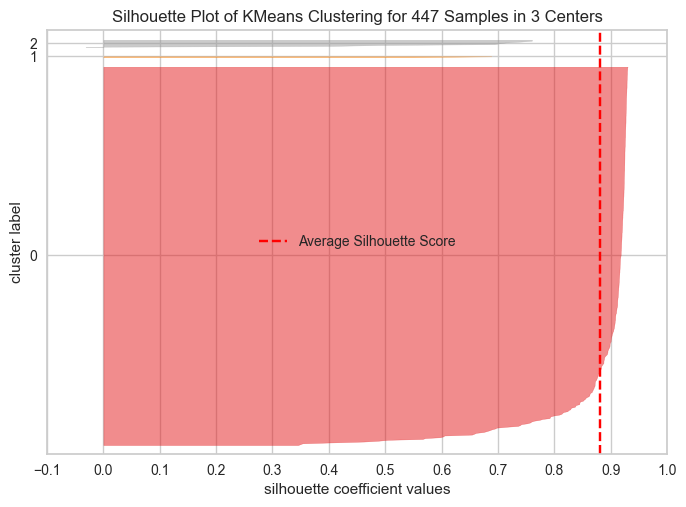

In [19]:
from yellowbrick.cluster import SilhouetteVisualizer

clusters = [2,3]

for cluster in clusters:
    
    print('-'*100)

    # define the model for K
    kmeans = KMeans(n_clusters = cluster, random_state=0)

    # pass the model through the visualizer
    visualizer = SilhouetteVisualizer(kmeans)

    # fit the data
    visualizer.fit(X_train_robust)

    # show the chart
    visualizer.poof()

----------------------------------------------------------------------------------------------------


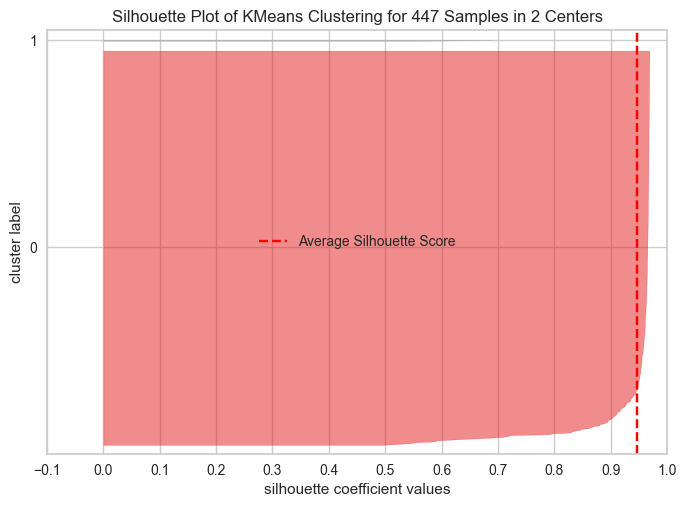

----------------------------------------------------------------------------------------------------


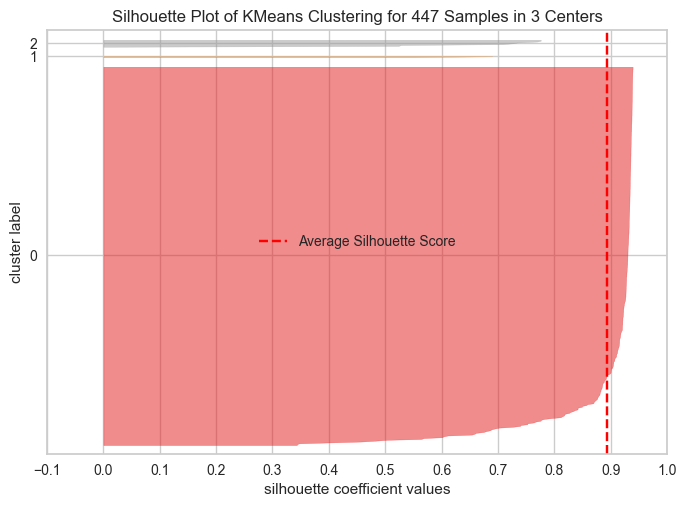

In [20]:
clusters = [2,3]

for cluster in clusters:

    print('-'*100)

    # define the model for K
    kmeans = KMeans(n_clusters = cluster, random_state=0)

    # pass the model through the visualizer
    visualizer = SilhouetteVisualizer(kmeans)

    # fit the data
    visualizer.fit(pca_dataset)

    # show the chart
    visualizer.poof()

## Clusters Visualization
***

Again, we will do this in the case of 2 and 3 clusters so we can visually see the difference.

----------------------------------------------------------------------------------------------------


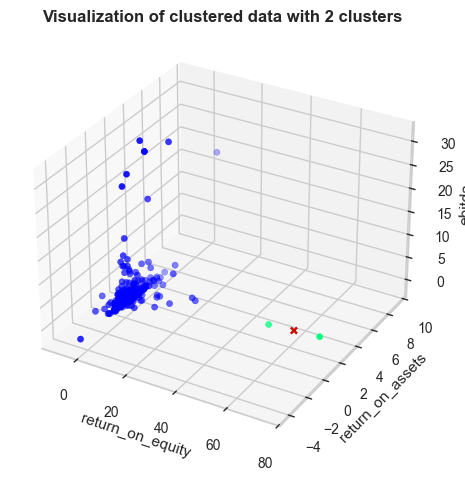

----------------------------------------------------------------------------------------------------


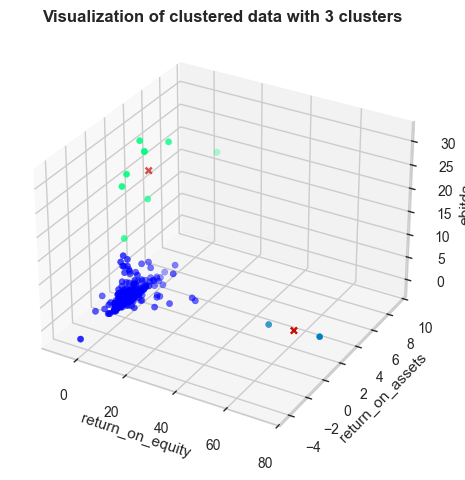

In [ ]:
clusters = [2,3]

for cluster in clusters:
    
    print('-'*100)
    
    kmeans = KMeans(n_clusters= cluster, random_state=0).fit(X_train_robust)
    
    # define the cluster centers
    cluster_centers = kmeans.cluster_centers_
    C1 = cluster_centers[:, 0]
    C2 = cluster_centers[:, 1]
    C3 = cluster_centers[:, 2]


    # create a new plot
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')

    # take the scaled data in this example.
    x = X_train_robust[:,0]
    y = X_train_robust[:,1]
    z = X_train_robust[:,2]

    # define the axes labels
    column_names = indicators_df.columns
    ax.set_xlabel(column_names[0])
    ax.set_ylabel(column_names[1])
    ax.set_zlabel(column_names[2])

    # create a new plot
    ax.scatter(x, y, z, c = kmeans.labels_.astype(float), cmap='winter')
    ax.scatter(C1, C2, C3, marker="x", color='r')

    plt.title('Visualization of clustered data with {} clusters'.format(cluster), fontweight='bold')

    plt.show()


Results interpritation:

* We have some companies who perform horribly across all three metrics, that would be the dark blue region in the lower left-hand corner. 
* Average company, denoted by the color green; these are companies who might beat on some metrics, lose on some, or do average. 
* Companies denoted in light blue and represent the companies who are performing very well with all metrics.

----------------------------------------------------------------------------------------------------


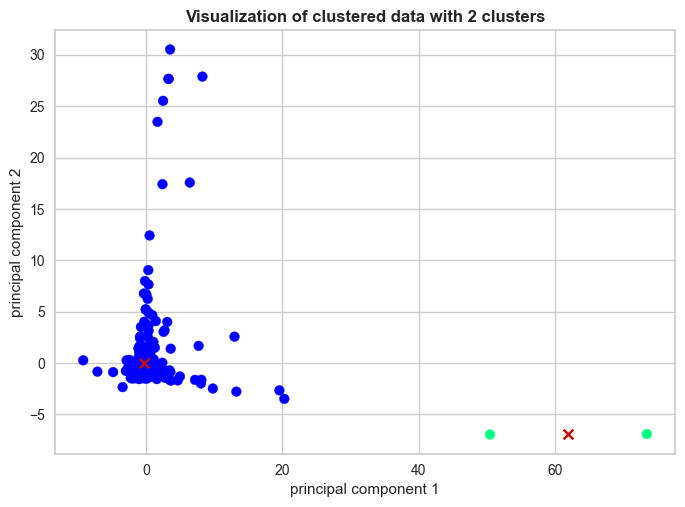

----------------------------------------------------------------------------------------------------


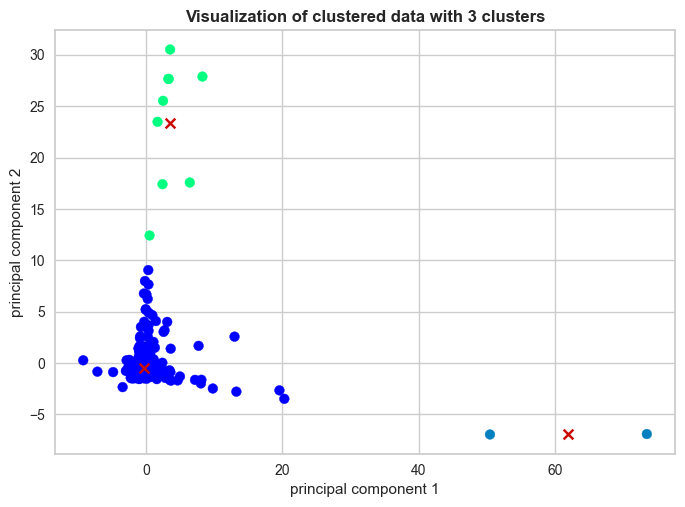

In [22]:
clusters = [2,3]

for cluster in clusters:
    
    print('-'*100)
    
    kmeans = KMeans(n_clusters= cluster, random_state=0).fit(pca_dataset)
    
    # define the cluster centers
    cluster_centers = kmeans.cluster_centers_
    C1 = cluster_centers[:, 0]
    C2 = cluster_centers[:, 1]

    # create a new plot
    plt.figure()

    # take the scaled data in this example.
    x = pca_dataset['principal component 1']
    y = pca_dataset['principal component 2']


    # define the axes labels
    column_names = pca_dataset.columns
    plt.xlabel(column_names[0])
    plt.ylabel(column_names[1])

    # Visualize it:
    plt.scatter(x, y, c=kmeans.labels_.astype(float), cmap='winter')
    plt.scatter(C1, C2, marker="x", color='r')

    # Plot the clustered data
    plt.title('Visualization of clustered data with {} clusters'.format(cluster), fontweight='bold')
    plt.show()



## Make Predictions


In [26]:
# grab the model
kmeans = results_dict[3]['model']

# define some test data
test_data = [
             [0.15,  # return_on_equity
              0.10,  # return_on_assets
              40]  # ebitda
              ]

# make some predictions, in this case let's pass through our test set.
kmeans.predict(test_data)

array([2], dtype=int32)